# Импорты, seed

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


os.makedirs("artifacts/figures", exist_ok=True)
runs_results = []


dataset_path = 'S12-hw-dataset.csv'

Device: cuda


# Данные, первичный анализ и Temporal Split

Размер датасета: 4320
Диапазон дат: с 2025-01-01 по 2025-06-29
Пропуски:
date      0
target    0
dtype: int64


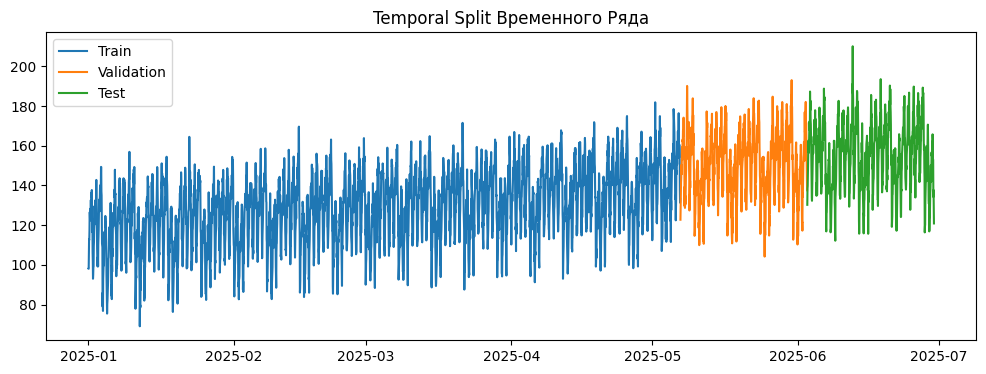

In [2]:
df = pd.read_csv(dataset_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Размер датасета: {len(df)}")
print(f"Диапазон дат: с {df['date'].min().date()} по {df['date'].max().date()}")
print(f"Пропуски:\n{df.isnull().sum()}")


df['target'] = df['target'].interpolate(method='linear')


n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()


plt.figure(figsize=(12, 4))
plt.plot(train_df['date'], train_df['target'], label='Train')
plt.plot(val_df['date'], val_df['target'], label='Validation')
plt.plot(test_df['date'], test_df['target'], label='Test')
plt.title("Temporal Split Временного Ряда")
plt.legend()
plt.savefig("artifacts/figures/series_split.png")
plt.show()

# Feature Engineering и Baselines (B1, B2, B3)

In [3]:
def create_features(data):
    d = data.copy()
    d['lag_1'] = d['target'].shift(1)
    d['lag_7'] = d['target'].shift(7)
    d['lag_14'] = d['target'].shift(14)
    d['rolling_mean_7'] = d['lag_1'].rolling(window=7).mean()
    d['rolling_std_7'] = d['lag_1'].rolling(window=7).std()
    d['dayofweek'] = d['date'].dt.dayofweek
    return d.dropna()

df_features = create_features(df)
train_f = df_features[df_features['date'] <= train_df['date'].max()]
val_f = df_features[(df_features['date'] > train_df['date'].max()) & (df_features['date'] <= val_df['date'].max())]
test_f = df_features[df_features['date'] > val_df['date'].max()]

features = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dayofweek']
X_train, y_train = train_f[features], train_f['target']
X_val, y_val = val_f[features], val_f['target']

scaler_b3 = StandardScaler()
X_train_scaled = scaler_b3.fit_transform(X_train)
X_val_scaled = scaler_b3.transform(X_val)

def calc_metrics(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mape': mean_absolute_percentage_error(y_true, y_pred)
    }


b1_preds = val_f['lag_1']
metrics_b1 = calc_metrics(y_val, b1_preds)


b2_preds = val_f['rolling_mean_7']
metrics_b2 = calc_metrics(y_val, b2_preds)


ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
b3_preds = ridge.predict(X_val_scaled)
metrics_b3 = calc_metrics(y_val, b3_preds)

for exp_id, m, notes in zip(['B1', 'B2', 'B3'], [metrics_b1, metrics_b2, metrics_b3], ['Naive last', 'MA 7', 'Ridge on lags']):
    runs_results.append({
        'experiment_id': exp_id, 'task': 'forecasting', 'dataset': 'S12', 'seed': 42,
        'split_summary': '70/15/15', 'window_size': None, 'horizon': 1, 'model_summary': notes,
        'features_summary': 'lags, rolling, calendar', 'scaler': 'StandardScaler', 'optimizer': None, 'lr': None,
        'epochs_trained': None, 'best_val_mae': m['mae'], 'best_val_rmse': m['rmse'], 'best_val_mape': m['mape'],
        'test_mae': None, 'test_rmse': None, 'test_mape': None, 'notes': notes
    })
    print(f"{exp_id} Val MAE: {m['mae']:.3f}")

B1 Val MAE: 6.445
B2 Val MAE: 12.702
B3 Val MAE: 7.189


# Оконное представление и GRU (R1)

In [4]:
WINDOW_SIZE = 14
BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3


scaler_rnn = StandardScaler()
train_scaled = scaler_rnn.fit_transform(train_df[['target']])
val_scaled = scaler_rnn.transform(val_df[['target']])
test_scaled = scaler_rnn.transform(test_df[['target']])

def create_sequences(data, window_size):
    xs, ys = [], []
    for i in range(len(data) - window_size):
        xs.append(data[i:(i + window_size)])
        ys.append(data[i + window_size])
    return np.array(xs), np.array(ys)

X_train_rnn, y_train_rnn = create_sequences(train_scaled, WINDOW_SIZE)
X_val_rnn, y_val_rnn = create_sequences(val_scaled, WINDOW_SIZE)

class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(TSDataset(X_train_rnn, y_train_rnn), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TSDataset(X_val_rnn, y_val_rnn), batch_size=BATCH_SIZE, shuffle=False)

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, h_n = self.gru(x)
        return self.fc(h_n[-1])

model = GRUModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses, val_losses = [], []
best_val_loss = float('inf')
best_weights = None

for epoch in range(EPOCHS):
    model.train()
    tr_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * len(X_batch)

    model.eval()
    vl_loss = 0
    val_preds_scaled = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            vl_loss += loss.item() * len(X_batch)
            val_preds_scaled.extend(preds.cpu().numpy())

    tr_loss /= len(X_train_rnn)
    vl_loss /= len(X_val_rnn)
    train_losses.append(tr_loss)
    val_losses.append(vl_loss)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_weights = model.state_dict().copy()


model.load_state_dict(best_weights)
val_preds_orig = scaler_rnn.inverse_transform(np.array(val_preds_scaled).reshape(-1, 1))
y_val_orig = scaler_rnn.inverse_transform(y_val_rnn)
metrics_r1 = calc_metrics(y_val_orig, val_preds_orig)

runs_results.append({
    'experiment_id': 'R1', 'task': 'forecasting', 'dataset': 'S12', 'seed': 42,
    'split_summary': '70/15/15', 'window_size': WINDOW_SIZE, 'horizon': 1, 'model_summary': 'GRU 64 units',
    'features_summary': 'raw sequence', 'scaler': 'StandardScaler', 'optimizer': 'Adam', 'lr': LR,
    'epochs_trained': EPOCHS, 'best_val_mae': metrics_r1['mae'], 'best_val_rmse': metrics_r1['rmse'], 'best_val_mape': metrics_r1['mape'],
    'test_mae': None, 'test_rmse': None, 'test_mape': None, 'notes': 'Best GRU'
})
print(f"R1 GRU Val MAE: {metrics_r1['mae']:.3f}")

R1 GRU Val MAE: 5.873


# Визуализация валидации, тест и сохранение артефактов

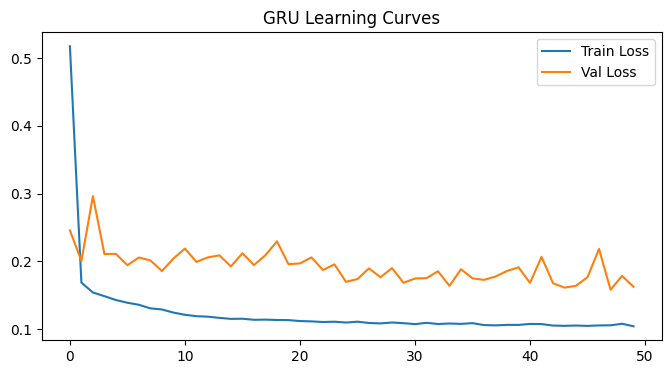

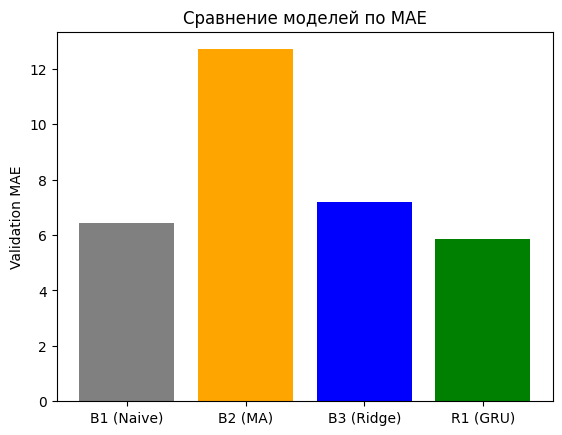

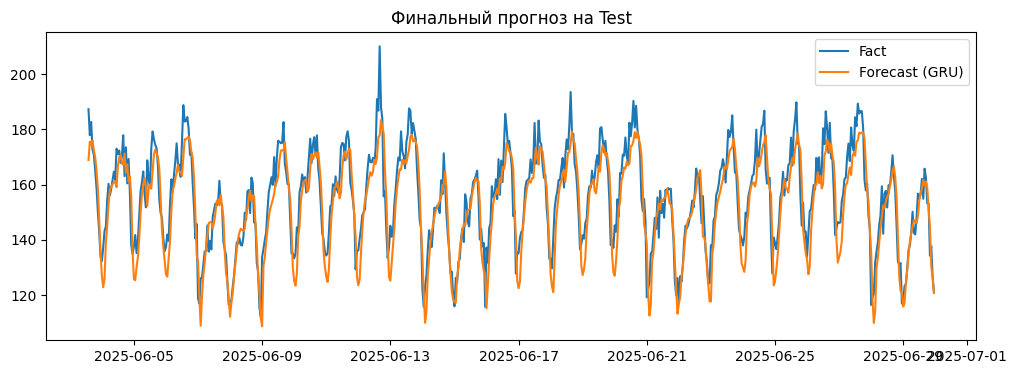

Финальный Test MAE: 6.600. Артефакты сохранены.


In [5]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title("GRU Learning Curves")
plt.legend()
plt.savefig("artifacts/figures/gru_learning_curves.png")
plt.show()


maes = [m['mae'] for m in [metrics_b1, metrics_b2, metrics_b3, metrics_r1]]
plt.bar(['B1 (Naive)', 'B2 (MA)', 'B3 (Ridge)', 'R1 (GRU)'], maes, color=['gray', 'orange', 'blue', 'green'])
plt.ylabel('Validation MAE')
plt.title('Сравнение моделей по MAE')
plt.savefig("artifacts/figures/baselines_compare.png")
plt.show()


X_test_rnn, y_test_rnn = create_sequences(test_scaled, WINDOW_SIZE)
test_loader = DataLoader(TSDataset(X_test_rnn, y_test_rnn), batch_size=BATCH_SIZE, shuffle=False)

model.eval()
test_preds_scaled = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        preds = model(X_batch.to(device))
        test_preds_scaled.extend(preds.cpu().numpy())

test_preds_orig = scaler_rnn.inverse_transform(np.array(test_preds_scaled).reshape(-1, 1))
y_test_orig = scaler_rnn.inverse_transform(y_test_rnn)
test_metrics = calc_metrics(y_test_orig, test_preds_orig)


runs_results[-1].update({'test_mae': test_metrics['mae'], 'test_rmse': test_metrics['rmse'], 'test_mape': test_metrics['mape']})


plt.figure(figsize=(12, 4))
plt.plot(test_df['date'].iloc[WINDOW_SIZE:], y_test_orig, label='Fact')
plt.plot(test_df['date'].iloc[WINDOW_SIZE:], test_preds_orig, label='Forecast (GRU)')
plt.title("Финальный прогноз на Test")
plt.legend()
plt.savefig("artifacts/figures/best_forecast_test.png")
plt.show()


torch.save(model.state_dict(), 'artifacts/best_gru.pt')
config = {
    "architecture": "GRU", "window_size": WINDOW_SIZE, "hidden_size": 64,
    "batch_size": BATCH_SIZE, "lr": LR, "seed": 42, "scaler": "StandardScaler"
}
with open('artifacts/best_gru_config.json', 'w') as f: json.dump(config, f)
pd.DataFrame(runs_results).to_csv('artifacts/runs.csv', index=False)
print(f"Финальный Test MAE: {test_metrics['mae']:.3f}. Артефакты сохранены.")